# Japan — Full Piotroski F-Score Study (formations 2023–2025)

The proposal's complete loop on **real data**: point-in-time universe →
high-B/M value subset → 9-signal F-Score → fixed-basket selection (F-Score vs
value / market-cap / liquidity-matched / random Monte-Carlo) → EW / GMV /
sector-capped GMV on RMT-cleaned covariances → annual-rebalance backtest →
placement in the random distribution → investable benchmarks → Fama-French
three-factor regression.

**Data & scope.** Yahoo Finance serves ~5 annual statement periods per name, which supports July-1 formations in **2023, 2024 and 2025** only; the evaluation window is capped at **2025-12-31** to stay inside the proposal's 2000–2025 sample (the final formation contributes a half holding year). Report dates are fiscal period ends; the reporting lag is 3 months — the statutory deadline for the securities report (yukashoken hokokusho), so a March fiscal year is public by end-June, just before formation. No free source provides 2000-2025 Japanese fundamentals (J-Quants free tier is 2 years; EDINET XBRL starts 2008 and needs the Japanese-GAAP taxonomy); extending Japan to the proposal window requires a licensed source (J-Quants paid tier / Refinitiv), which plugs into the same canonical schemas. Universe membership is current Nikkei 225 members — a survivorship caveat documented in `src/fscore/data/universe.py`.

Run `python scripts/fetch_us_japan.py`
once before this notebook (builds the git-ignored cache under `data/`).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.yahoo import load_cached
from fscore.pipeline import run_study
from fscore.evaluation import (metrics, benchmark_returns, fetch_ff_factors,
                               factor_regression, to_usd)

MARKET = "japan"
YEARS = [2023, 2024, 2025]
LAG_MONTHS = 3  # report_date = fiscal period end (no filing dates on Yahoo)
END_CAP = pd.Timestamp("2025-12-31")  # proposal sample ends in 2025
fund, prices, sectors, bench = load_cached(MARKET, ROOT / "data")
membership = None
print(f"fundamentals: {fund.ticker.nunique()} tickers, "
      f"FY{fund.fiscal_year.min()}–FY{fund.fiscal_year.max()}")
print(f"prices: {prices.ticker.nunique()} tickers, "
      f"{prices.date.min():%Y-%m-%d} → {prices.date.max():%Y-%m-%d}")
fund.groupby("fiscal_year").size().rename("statements")

fundamentals: 223 tickers, FY2021–FY2025
prices: 223 tickers, 2022-01-04 → 2026-07-17


fiscal_year
2021    133
2022    221
2023    223
2024    223
2025    205
Name: statements, dtype: int64

### 1. Run the multi-year study

Per formation year: universe = top-150 names by median dollar volume with
continuous listing and complete, published statements; value subset = top 40%
by B/M (~60 names); baskets of 30; 1,000 random baskets under EW (300 pushed
through the GMV / sector-GMV pipeline).

In [2]:
study = run_study(MARKET, fund, prices, sectors, YEARS,
                  n_mc=1000, n_mc_opt=300, lag_months=LAG_MONTHS,
                  membership=membership, end_cap=END_CAP, seed=42)
diag = pd.DataFrame([{"year": yr.year, **yr.diagnostics} for yr in study.yearly])
diag.set_index("year")

,universe,value_set,scored,k,fscore_mean,fscore_basket_min
year,,,,,,
2023,118,47,8,8,6.250000,3
2024,150,60,60,30,6.000000,6
2025,150,60,60,30,6.233333,6


### 2. F-Score distribution within the value universe, per formation

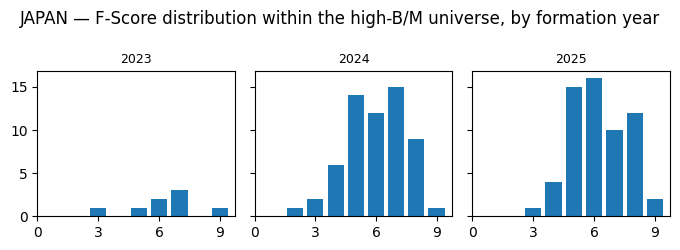

,2023,2024,2025
count,8.00,60.0,60.00
mean,6.25,6.0,6.23
std,1.75,1.5,1.38
min,3.00,2.0,3.00
25%,5.75,5.0,5.00
50%,6.50,6.0,6.00
75%,7.00,7.0,7.00
max,9.00,9.0,9.00


In [3]:
ncol = min(5, len(YEARS))
nrow = -(-len(YEARS) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(2.3 * ncol, 2.5 * nrow),
                         sharey=True, squeeze=False)
for ax, yr in zip(axes.flat, study.yearly):
    counts = yr.scored.fscore.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{yr.year}", fontsize=9); ax.set_xticks(range(0, 10, 3))
for ax in axes.flat[len(study.yearly):]:
    ax.axis("off")
fig.suptitle(f"{MARKET.upper()} — F-Score distribution within the high-B/M universe, by formation year")
plt.tight_layout(); plt.show()

pd.DataFrame({yr.year: yr.scored.fscore.describe() for yr in study.yearly}).round(2)

### 3. Chained track record vs investable benchmarks

1306.T is JPY like the portfolios; EWJV is USD, so its row mixes in currency effects and is indicative only.

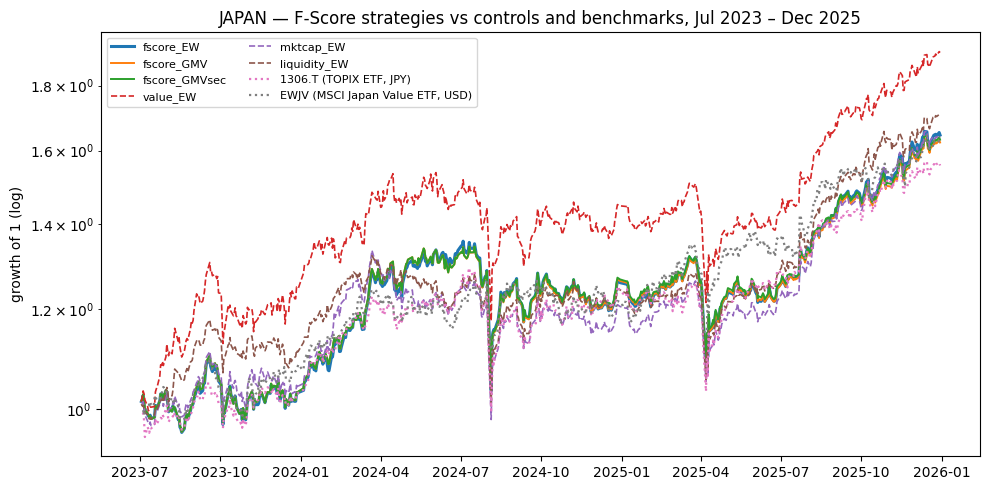

In [4]:
BENCH = {"1306.T (TOPIX ETF, JPY)": "1306.T",
         "EWJV (MSCI Japan Value ETF, USD)": "EWJV"}
start, end = study.daily.index.min(), study.daily.index.max()
bench_rets = {name: benchmark_returns(bench, tk, start, end)
              for name, tk in BENCH.items()}

nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(10, 5))
styles = {"fscore_EW": ("-", 2.2), "fscore_GMV": ("-", 1.4), "fscore_GMVsec": ("-", 1.4),
          "value_EW": ("--", 1.2), "mktcap_EW": ("--", 1.2), "liquidity_EW": ("--", 1.2)}
for s in study.daily.columns:
    ls, lw = styles[s]
    ax.plot(nav.index, nav[s], ls, lw=lw, label=s)
for name, r in bench_rets.items():
    ax.plot((1 + r).cumprod(), ":", lw=1.6, label=name)
ax.set_ylabel("growth of 1 (log)"); ax.set_yscale("log")
ax.set_title(f"{MARKET.upper()} — F-Score strategies vs controls and benchmarks, "
             f"{start:%b %Y} – {end:%b %Y}")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

In [5]:
tbl = study.summary()
for name, r in bench_rets.items():
    tbl.loc[name] = metrics(r)
tbl.round(3)

,cum_return,ann_return,ann_vol,sharpe,max_drawdown
fscore_EW,0.646,0.229,0.218,1.049,-0.238
fscore_GMV,0.624,0.222,0.216,1.025,-0.232
fscore_GMVsec,0.632,0.224,0.215,1.041,-0.230
value_EW,0.912,0.307,0.235,1.305,-0.236
mktcap_EW,0.639,0.226,0.214,1.056,-0.264
liquidity_EW,0.703,0.246,0.205,1.202,-0.237
"1306.T (TOPIX ETF, JPY)",0.557,0.200,0.204,0.983,-0.228
"EWJV (MSCI Japan Value ETF, USD)",0.626,0.216,0.182,1.187,-0.146


### 4. Statistical control — placement in the Monte-Carlo random distribution

Same universe, same basket size, same construction pipeline; the only
difference is *which* 30 names. Percentile = share of random baskets the
F-Score portfolio beats; p-value is one-sided.

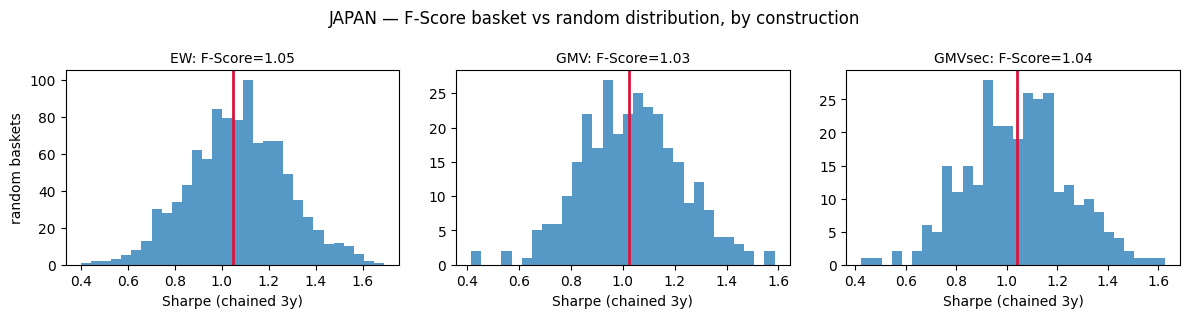

fscore  random_mean  random_std  percentile  \
fscore_EW     ann_return     0.229        0.231       0.045       0.471   
              sharpe         1.049        1.070       0.206       0.455   
              max_drawdown  -0.238       -0.234       0.017       0.631   
fscore_GMV    ann_return     0.222        0.219       0.042       0.520   
              sharpe         1.025        1.033       0.193       0.493   
              max_drawdown  -0.232       -0.231       0.017       0.537   
fscore_GMVsec ann_return     0.224        0.221       0.043       0.507   
              sharpe         1.041        1.043       0.200       0.480   
              max_drawdown  -0.230       -0.230       0.017       0.523   

                            p_value  n_draws  
fscore_EW     ann_return      0.529   1000.0  
              sharpe          0.545   1000.0  
              max_drawdown    0.369   1000.0  
fscore_GMV    ann_return      0.480    300.0  
              sharpe          0.507    300.0  
              max_drawdown    0.463    300.0  
fscore_GMVsec ann_return      0.493    300.0  
              sharpe          0.520    300.0  
              max_drawdown    0.477    300.0

In [6]:
pairs = [("EW", "fscore_EW"), ("GMV", "fscore_GMV"), ("GMVsec", "fscore_GMVsec")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=False)
for ax, (how, strat) in zip(axes, pairs):
    sharpes = study.mc_summary(how)["sharpe"].dropna()
    fs = metrics(study.daily[strat].dropna())["sharpe"]
    ax.hist(sharpes, bins=30, alpha=0.75)
    ax.axvline(fs, color="crimson", lw=2)
    ax.set_title(f"{how}: F-Score={fs:.2f}", fontsize=10)
    ax.set_xlabel(f"Sharpe (chained {len(YEARS)}y)")
axes[0].set_ylabel("random baskets")
fig.suptitle(f"{MARKET.upper()} — F-Score basket vs random distribution, by construction")
plt.tight_layout(); plt.show()

placements = pd.concat({strat: study.placement(strat, how) for how, strat in pairs})
placements.round(3)

### 5. Turnover and implied trading cost

One-way turnover between consecutive annual rebalances; cost drag assumes
20 bp per side (2 x turnover x 20 bp per year).

In [7]:
to = study.turnover_table()
to.loc["mean"] = to.mean()
cost = (2 * to.loc["mean"] * 0.0020).rename("annual cost drag")
pd.concat([to.round(3).T, cost.round(4)], axis=1)

,2024,2025,mean,annual cost drag
fscore_EW,0.967,0.600,0.783,0.0031
fscore_GMV,0.969,0.648,0.808,0.0032
fscore_GMVsec,0.971,0.640,0.806,0.0032
value_EW,0.800,0.267,0.533,0.0021
mktcap_EW,0.800,0.300,0.550,0.0022
liquidity_EW,0.967,0.633,0.800,0.0032


### 6. Does alpha survive the factor exposures?

Daily excess returns regressed on the Fama-French three factors (market,
size, value) with Newey-West standard errors. Japan portfolio returns are converted to USD to match the USD-denominated Japan factor set.

In [8]:
ff = fetch_ff_factors("japan")
# Ken French Japan factors are USD-denominated -> convert JPY returns to USD
fx = bench[bench.ticker == "JPY=X"].set_index("date")["adj_close"]
series = {s: to_usd(study.daily[s].dropna(), fx)
          for s in ["fscore_EW", "fscore_GMV", "value_EW"]}
reg = pd.DataFrame({s: factor_regression(r, ff) for s, r in series.items()}).T
reg.round(4)

,alpha_daily,alpha_annual,alpha_tstat,alpha_pvalue,beta_mkt,beta_smb,beta_hml,r2,n_obs
fscore_EW,0.0002,0.0399,0.5561,0.5781,0.6842,0.0701,0.1310,0.5101,609.0
fscore_GMV,0.0001,0.0257,0.3630,0.7166,0.6784,0.0751,0.1760,0.5149,609.0
value_EW,0.0002,0.0468,0.5895,0.5555,0.6961,0.1084,0.4392,0.4907,609.0


In [9]:
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
tbl.to_csv(RESULTS / f"{MARKET}_summary.csv")
placements.to_csv(RESULTS / f"{MARKET}_mc_placement.csv")
to.to_csv(RESULTS / f"{MARKET}_turnover.csv")
reg.to_csv(RESULTS / f"{MARKET}_factor_regression.csv")
diag.to_csv(RESULTS / f"{MARKET}_diagnostics.csv", index=False)
print("saved to", RESULTS)

saved to C:\Users\miked\OneDrive\Desktop\Career\WQU\Cap Project\fscore_capstone\results


### 7. Reading the results

**Selection.** Over the capped window (Jul 2023 – Dec 2025) the F-Score basket
(EW, Sharpe 1.05, 22.9% ann.) sits near the **middle of the random
distribution** (45–47th percentile for Sharpe and return, one-sided p ≈ 0.5):
in this short, strongly rallying Japanese value market, the score did not
select better than chance among high-B/M names. The pure value screen
(top-B/M, Sharpe 1.31) outperformed it, so the F-Score added nothing beyond
the value tilt here.

**Construction.** GMV and sector-capped GMV on the F-Score basket land within
±0.03 Sharpe of equal weighting with marginally shallower drawdowns —
RMT-cleaned optimization neither created nor destroyed value on a 30-name
basket in this window.

**Practicality.** All strategies beat the buy-and-hold TOPIX ETF (20.0% ann.)
before costs; annual turnover ~0.78 implies only ~30 bp of drag at 20 bp per
side. The FF3 regression shows the expected value loading (HML ≈ 0.13) and an
**insignificant** alpha (≈ 4% p.a., t = 0.56).

**Caveats before reading anything into this.** Three formations only; the 2023
formation has just 8 scoreable names (Yahoo's oldest statement year is
sparse, and firms missing prior-year inputs are excluded rather than scored);
current-constituent universe. The developed-pair comparison in the report
should lean on the 15-year US study; Japan's verdict stays provisional until
licensed long-history data (J-Quants / Refinitiv) replaces the Yahoo feed.
